In [49]:
import ast
import json
from pathlib import Path
import seaborn as sns 


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [50]:
# 1) Define the base folder *relative* to your notebook/script
current_Path = Path.cwd()
BASE = current_Path.parent
print(BASE)

# 2) Import the train and test file
test_file_dir = BASE / "data_curation" / "original_curated_with_embeddings_and_MW" / "test_predictions" / "consensus_without_data_augmentation.csv"
train_file_dir = BASE / "data_curation" / "original_curated_with_embeddings_and_MW" / "train_without_data_augmentation" / "final_train_df.csv"

# 3) Load dataframe 
test_df = pd.read_csv(test_file_dir)
train_df = pd.read_csv(train_file_dir)

/Users/sdl5_mp/Documents/GitHub/SDL5_MP


In [51]:
test_df.head()

,SMILES,exp MP,GNN1,GNN2,GNN3,GNN4,GNN5,GNN6,GNN7,GNN8,GNN9,GNN10,Consensus,SD,embeddings,MW
0,BrB(Br)Br,-46.0,6.68,-15.38,-39.90,-13.48,27.42,-36.55,-34.78,11.39,-2.45,16.05,-8.10,22.56,"tensor([0.0000e+00, 2.8810e-01, 0.0000e+00, 3....",250.524
1,O=S(c1ccccc1)c1ccccc1,71.0,125.03,70.92,78.64,72.86,105.50,82.85,67.80,74.79,71.09,75.56,82.50,17.42,"tensor([0.2024, 0.0000, 0.0000, 0.3615, 0.1873...",202.278
2,CC1(C)CC1,-109.0,-23.60,-71.54,-0.92,-55.88,23.92,-6.40,17.94,-10.58,-31.12,-13.09,-17.13,28.38,"tensor([2.3516e-01, 9.4132e-01, 5.2410e-01, 3....",70.135
3,CCCCCCCCCCS(=O)(=O)Cl,32.0,29.51,0.79,36.51,15.82,19.24,32.58,15.15,7.75,38.27,4.85,20.05,12.83,"tensor([3.2476e-01, 4.7666e-01, 5.3061e-01, 1....",240.796
4,N#CC(Nc1nc(NC2CC2)nc(n1)Cl)(C)C,170.0,165.87,191.20,158.89,170.67,194.67,169.77,176.28,163.49,179.58,120.81,169.12,19.45,"tensor([5.9145e-02, 3.7941e-01, 4.0317e-01, 1....",252.709


In [52]:
train_df.head()

,SMILES,MP,embeddings,MW
0,FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...,-20.0,"tensor([3.5142e-01, 9.1762e-01, 8.4583e-02, 3....",624.106
1,CCc1ncc[nH]1,82.0,"tensor([2.2764e-01, 0.0000e+00, 0.0000e+00, 8....",96.133
2,S=C(N(C)C)Sc1ccc2c(c1)cccc2,114.0,"tensor([3.4984e-01, 4.8049e-02, 8.2259e-02, 2....",247.388
3,Nc1nc(N)nc(n1)c1ccccc1,227.0,"tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 3....",187.206
4,NCCNc1ccc(cn1)[N+](=O)[O-],127.0,"tensor([7.3705e-02, 7.5921e-02, 1.7240e-01, 1....",182.183


In [53]:
t1, t2 = 250, 500
print(f"Ranges (based on TRAIN): Low ≤ {t1}, Intermediate ({t1}, {t2}], High > {t2}")

def mw_default_thresholds(mw_series, t1=250, t2=500):
    return np.select(
        [mw_series <= t1, mw_series > t2],
        ["Low", "High"],
        default="Intermediate"
    )

train_df["MW_category_default"] = mw_default_thresholds(train_df["MW"], t1, t2)
test_df["MW_category_default"]  = mw_default_thresholds(test_df["MW"],  t1, t2)

Ranges (based on TRAIN): Low ≤ 250, Intermediate (250, 500], High > 500


In [54]:
test_df.head()

,SMILES,exp MP,GNN1,GNN2,GNN3,GNN4,GNN5,GNN6,GNN7,GNN8,GNN9,GNN10,Consensus,SD,embeddings,MW,MW_category_default
0,BrB(Br)Br,-46.0,6.68,-15.38,-39.90,-13.48,27.42,-36.55,-34.78,11.39,-2.45,16.05,-8.10,22.56,"tensor([0.0000e+00, 2.8810e-01, 0.0000e+00, 3....",250.524,Intermediate
1,O=S(c1ccccc1)c1ccccc1,71.0,125.03,70.92,78.64,72.86,105.50,82.85,67.80,74.79,71.09,75.56,82.50,17.42,"tensor([0.2024, 0.0000, 0.0000, 0.3615, 0.1873...",202.278,Low
2,CC1(C)CC1,-109.0,-23.60,-71.54,-0.92,-55.88,23.92,-6.40,17.94,-10.58,-31.12,-13.09,-17.13,28.38,"tensor([2.3516e-01, 9.4132e-01, 5.2410e-01, 3....",70.135,Low
3,CCCCCCCCCCS(=O)(=O)Cl,32.0,29.51,0.79,36.51,15.82,19.24,32.58,15.15,7.75,38.27,4.85,20.05,12.83,"tensor([3.2476e-01, 4.7666e-01, 5.3061e-01, 1....",240.796,Low
4,N#CC(Nc1nc(NC2CC2)nc(n1)Cl)(C)C,170.0,165.87,191.20,158.89,170.67,194.67,169.77,176.28,163.49,179.58,120.81,169.12,19.45,"tensor([5.9145e-02, 3.7941e-01, 4.0317e-01, 1....",252.709,Intermediate


In [55]:
train_df.head()

,SMILES,MP,embeddings,MW,MW_category_default
0,FC1(F)C(F)(F)C(F)(F)C(C2(C1(F)C1(F)C(F)(F)C(F)...,-20.0,"tensor([3.5142e-01, 9.1762e-01, 8.4583e-02, 3....",624.106,High
1,CCc1ncc[nH]1,82.0,"tensor([2.2764e-01, 0.0000e+00, 0.0000e+00, 8....",96.133,Low
2,S=C(N(C)C)Sc1ccc2c(c1)cccc2,114.0,"tensor([3.4984e-01, 4.8049e-02, 8.2259e-02, 2....",247.388,Low
3,Nc1nc(N)nc(n1)c1ccccc1,227.0,"tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 3....",187.206,Low
4,NCCNc1ccc(cn1)[N+](=O)[O-],127.0,"tensor([7.3705e-02, 7.5921e-02, 1.7240e-01, 1....",182.183,Low


In [56]:
missing_count_test = test_df["MW"].isna().sum()
missing_count_train = train_df["MW"].isna().sum()
print(f"Missing MW for train (no augmentation): {missing_count_test} " + " Missing Count for test: {missing_count_test}")

Missing MW for train (no augmentation): 0  Missing Count for test: {missing_count_test}


In [57]:
train_df.describe()

,MP,MW
count,17633.00000,17633.000000
mean,103.61293,238.282966
std,91.08719,108.332862
min,-205.00000,16.043000
25%,47.00000,164.013000
50%,106.00000,215.337000
75%,167.00000,294.339000
max,517.00000,1701.206000


In [58]:
test_df[["exp MP", "MW"]].describe()

,exp MP,MW
count,1961.000000,1961.000000
mean,104.750653,239.068269
std,89.959163,107.479056
min,-184.000000,18.015000
25%,48.000000,165.192000
50%,107.000000,215.043000
75%,166.500000,299.282000
max,505.000000,922.572000


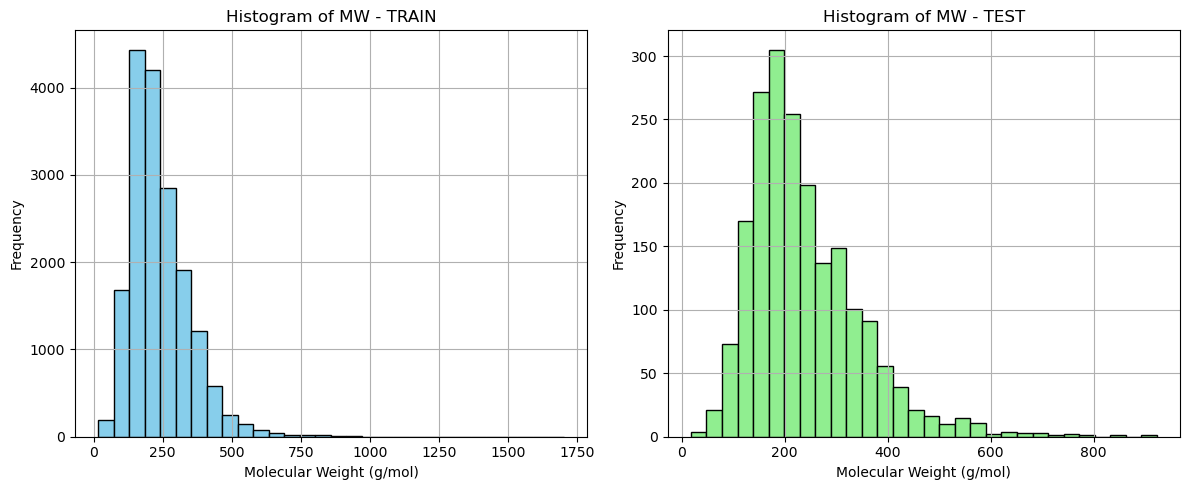

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# MW distribution for train
plt.subplot(1, 2, 1)  
plt.hist(train_df["MW"], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of MW - TRAIN')
plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('Frequency')
plt.grid(True)

# MW distribution for test
plt.subplot(1, 2, 2)
plt.hist(test_df["MW"], bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of MW - TEST')
plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

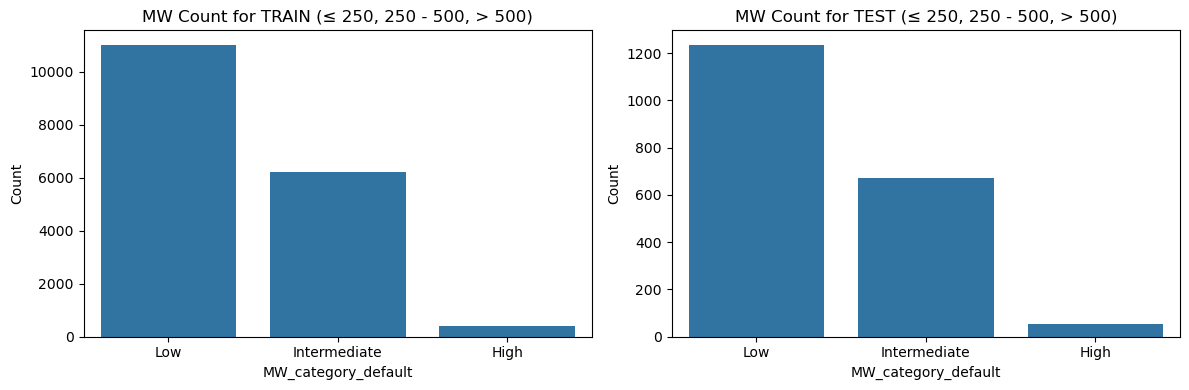

In [65]:
plt.figure(figsize=(12, 4))

# Quantile-based (TRAIN)
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x="MW_category_default", order=['Low', 'Intermediate', 'High'])
plt.title('MW Count for TRAIN (≤ 250, 250 - 500, > 500)')
plt.ylabel('Count')

# Fixed thresholds (TEST)
plt.subplot(1, 2, 2)
sns.countplot(data=test_df, x="MW_category_default", order=['Low', 'Intermediate', 'High'])
plt.title('MW Count for TEST (≤ 250, 250 - 500, > 500)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [70]:
print(test_df["MW_category_default"].value_counts())

MW_category_default
Low             1235
Intermediate     672
High              54
Name: count, dtype: int64


In [71]:
print(train_df["MW_category_default"].value_counts())

MW_category_default
Low             11006
Intermediate     6217
High              410
Name: count, dtype: int64


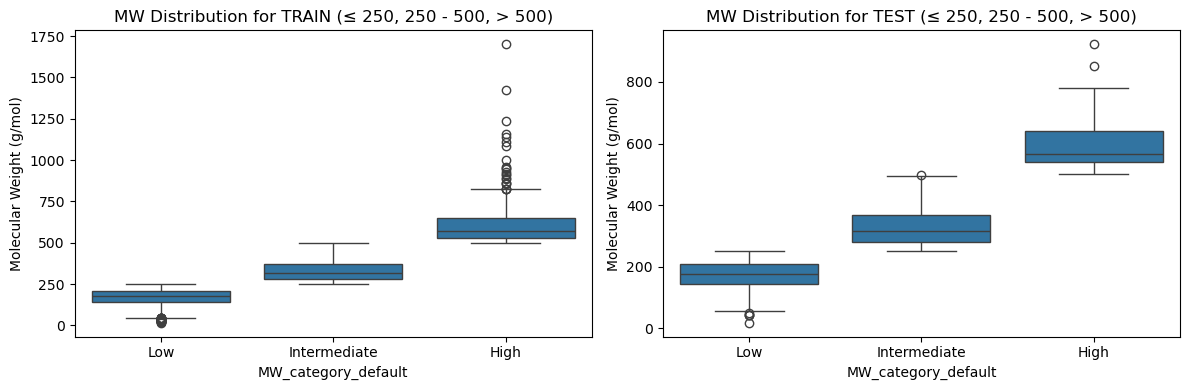

In [67]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=train_df, x="MW_category_default", y="MW", order=['Low', 'Intermediate', 'High'])
plt.title('MW Distribution for TRAIN (≤ 250, 250 - 500, > 500)')
plt.ylabel('Molecular Weight (g/mol)')

plt.subplot(1, 2, 2)
sns.boxplot(data=test_df, x="MW_category_default", y="MW", order=['Low', 'Intermediate', 'High'])
plt.title('MW Distribution for TEST (≤ 250, 250 - 500, > 500)')
plt.ylabel('Molecular Weight (g/mol)')

plt.tight_layout()
plt.show()
